# Does a protein's *chemistry* explain how confident AlphaFold is?

### An AP Biology / AP Chemistry investigation using real structural data

In 2021, an AI system called **AlphaFold** did something biologists had been trying to do
for fifty years: it learned to predict a protein's three-dimensional shape from nothing but
its amino acid sequence. Predictions for essentially every known protein are now free to
download.

Here's the part that makes it interesting for us. AlphaFold doesn't just hand you a shape —
it also tells you **how sure it is about every single amino acid**, on a scale from 0 to 100.
That score is called **pLDDT**. Some residues get a 98. Some get a 33. In the same protein.

So: **why?** What makes AlphaFold confident about one amino acid and unsure about the one
twelve positions later?

This notebook tests one specific idea:

> **Hypothesis.** A residue's *chemistry* — whether its side chain is nonpolar, polar,
> acidic, or basic — is related to how confidently AlphaFold can place it.

We'll find out that the answer is **yes, but not for the reason you'd first guess** — and
chasing down that "but" is where the real science happens.

No prior statistics required. Every statistical idea — standard deviation, confidence
interval, *p*-value, correlation — is explained from scratch as we need it.

---

## Where we're going

| Section | Question we're asking | New statistical tool |
|---|---|---|
| 1 | What does AlphaFold actually give us? | — |
| 2 | What are the 20 amino acids, chemically? | — |
| 3 | What is our protein made of? | Describing a distribution |
| 4 | Does confidence differ by side-chain class? | Confidence intervals, *t*-test, effect size |
| 5 | Can we compare all five classes at once? | One-way ANOVA |
| 6 | What does this look like in 3D? | — |
| 7 | Are nonpolar residues really buried? | Chi-square test |
| 8 | How strong is the relationship? | Regression, *r* and *r²* |
| 9 | Wait — is something else causing this? | Confounding variables |
| 10 | What did we actually learn? | Limitations |

Our main subject is **human lysozyme**, the enzyme in your tears and saliva that kills
bacteria by cutting open their cell walls. It's small (148 amino acids), extremely
well-studied, and completely folded — which makes it a clean place to start.

---

## Setup

We need five tools:

| Library | What we use it for |
|---|---|
| `requests` | downloading real data from the AlphaFold database over the internet |
| `numpy` | fast math on arrays of numbers |
| `pandas` | spreadsheet-like tables (`DataFrame`s) |
| `matplotlib` | every chart in this notebook |
| `scipy.stats` | the statistical tests |

### One important habit: cache your data

This notebook downloads data from live scientific databases. Those databases get updated,
go down for maintenance, and occasionally change their formats. If we re-downloaded
everything on every run, our numbers could silently change from one day to the next — and
in science, **a result you can't reproduce isn't really a result.**

So the `fetch_cached()` function below saves every download to a `data/` folder the first
time, then reads from that folder afterward. Two details worth noticing:

- `resp.raise_for_status()` makes the code **crash loudly** if a download fails. That sounds
  bad, but the alternative is worse: silently continuing with missing data and reporting
  confident conclusions built on nothing.
- The cached files get committed alongside this notebook, so anyone who downloads this
  repository gets the exact numbers you see here.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


def fetch_cached(url, filename, as_json=True):
    # Download `url` once, cache it in data/<filename>, and reuse it on later runs.
    # Raises on any failed download rather than quietly returning empty data.
    path = DATA_DIR / filename
    if path.exists():
        text = path.read_text(encoding="utf-8")
        source = "cache"
    else:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()          # fail loudly, never silently
        text = resp.text
        path.write_text(text, encoding="utf-8")
        source = "downloaded"
    print(f"  {filename:32s} ({source}, {len(text)/1000:.0f} KB)")
    return json.loads(text) if as_json else text


print("Setup complete.")

Setup complete.


---

# 1. What does AlphaFold actually give us?

Let's meet our protein.

**Human lysozyme** is an enzyme found in tears, saliva, and mucus. It's part of your innate
immune system: it attacks bacteria by hydrolyzing the β(1→4) glycosidic bonds in
peptidoglycan, the mesh that gives a bacterial cell wall its strength. Cut enough of those
bonds and the bacterium bursts from its own internal osmotic pressure.

It is 148 amino acids long — small enough to reason about, big enough to have a real folded
core. Its UniProt accession number (a unique ID for a protein, like an ISBN for a book) is
**P61626**.

We ask the AlphaFold database for three things:

1. **The entry record** — metadata about the prediction
2. **The pLDDT scores** — one confidence number per amino acid
3. **The PDB file** — the actual 3D coordinates of every atom

In [2]:
LYSOZYME = "P61626"

print("Fetching human lysozyme:")
entry = fetch_cached(f"https://alphafold.ebi.ac.uk/api/prediction/{LYSOZYME}", "lysozyme_entry.json")[0]
plddt_doc = fetch_cached(entry["plddtDocUrl"], "lysozyme_plddt.json")
pdb_text = fetch_cached(entry["pdbUrl"], "lysozyme.pdb", as_json=False)

sequence = entry["sequence"]
scores = np.array(plddt_doc["confidenceScore"])

# Sanity check: the sequence and the score list must describe the same protein.
# Silently mismatched lengths would quietly corrupt everything downstream.
assert len(sequence) == len(scores), f"length mismatch: {len(sequence)} vs {len(scores)}"

lyso = pd.DataFrame({
    "position": np.arange(1, len(sequence) + 1),
    "aa": list(sequence),
    "pLDDT": scores,
})

print()
print("Protein:        ", entry["uniprotDescription"])
print("Gene:           ", entry["gene"])
print("Length:         ", len(sequence), "amino acids")
print("First 30 residues:", sequence[:30], "...")
print()
print(f"Mean pLDDT:      {lyso['pLDDT'].mean():.2f}")
print(f"Lowest pLDDT:    {lyso['pLDDT'].min():.2f}  (at position {lyso.loc[lyso['pLDDT'].idxmin(), 'position']})")
print(f"Highest pLDDT:   {lyso['pLDDT'].max():.2f}  (at position {lyso.loc[lyso['pLDDT'].idxmax(), 'position']})")

lyso.head()

Fetching human lysozyme:
  lysozyme_entry.json              (cache, 2 KB)
  lysozyme_plddt.json              (cache, 2 KB)
  lysozyme.pdb                     (cache, 99 KB)

Protein:         Lysozyme C
Gene:            LYZ
Length:          148 amino acids
First 30 residues: MKALIVLGLVLLSVTVQGKVFERCELARTL ...

Mean pLDDT:      94.07
Lowest pLDDT:    45.06  (at position 2)
Highest pLDDT:   98.94  (at position 27)


,position,aa,pLDDT
0,1,M,46.31
1,2,K,45.06
2,3,A,53.47
3,4,L,58.12
4,5,I,58.97


### Reading a pLDDT score

pLDDT stands for *predicted Local Distance Difference Test*. Ignore the name; what matters
is the interpretation. It is AlphaFold's own answer to the question *"if someone determined
this structure experimentally, how close would my prediction be, right here at this
residue?"*

The AlphaFold team defines four standard bands:

| pLDDT | Meaning | Official color |
|---|---|---|
| **> 90** | Very high — expect near-experimental accuracy | dark blue |
| **70 – 90** | Confident — the backbone is probably right | light blue |
| **50 – 70** | Low — treat with caution | yellow |
| **< 50** | Very low — often means the region has *no single stable shape at all* | orange |

That last row is the surprising one, and it will matter a lot later. A very low score is
usually not AlphaFold failing. It's AlphaFold correctly reporting that there is nothing
fixed to predict.

Let's look at every residue of lysozyme at once, two ways.

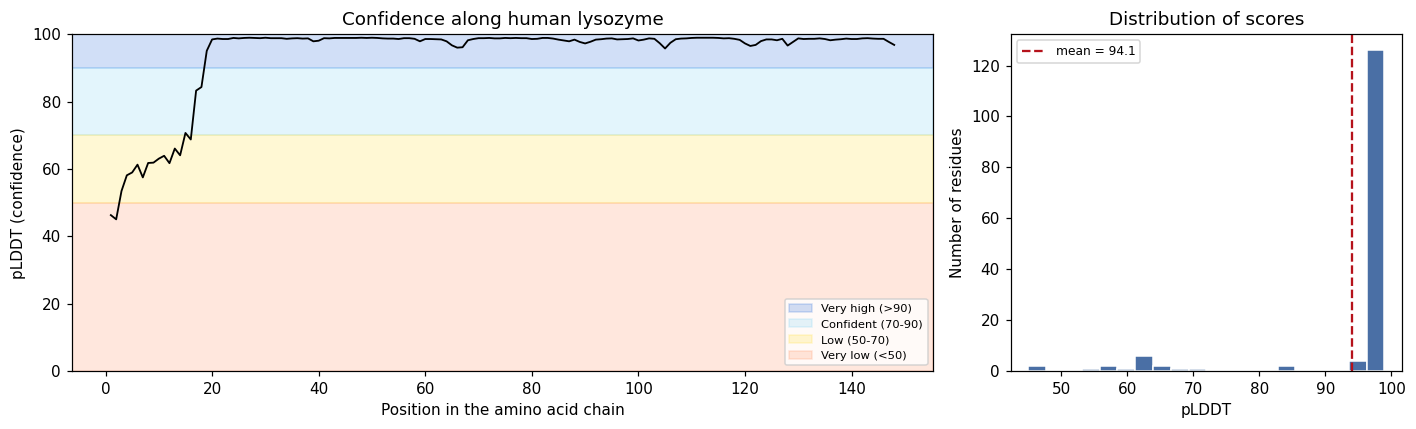

pLDDT
Very high (>90)      130
Confident (70-90)      3
Low (50-70)           13
Very low (<50)         2


In [3]:
BANDS = [(90, 100, "#0053D6", "Very high (>90)"),
         (70, 90, "#65CBF3", "Confident (70-90)"),
         (50, 70, "#FFDB13", "Low (50-70)"),
         (0, 50, "#FF7D45", "Very low (<50)")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2.2, 1]})

# Left: confidence along the amino acid chain
for low, high, color, label in BANDS:
    ax1.axhspan(low, high, color=color, alpha=0.18, label=label)
ax1.plot(lyso["position"], lyso["pLDDT"], color="black", linewidth=1.2)
ax1.set_xlabel("Position in the amino acid chain")
ax1.set_ylabel("pLDDT (confidence)")
ax1.set_title("Confidence along human lysozyme")
ax1.set_ylim(0, 100)
ax1.legend(loc="lower right", fontsize=7.5)

# Right: the same numbers as a distribution
ax2.hist(lyso["pLDDT"], bins=20, color="#4A6FA5", edgecolor="white")
ax2.axvline(lyso["pLDDT"].mean(), color="#B5121B", linestyle="--", linewidth=1.5,
            label=f"mean = {lyso['pLDDT'].mean():.1f}")
ax2.set_xlabel("pLDDT")
ax2.set_ylabel("Number of residues")
ax2.set_title("Distribution of scores")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

band_counts = pd.cut(lyso["pLDDT"], bins=[0, 50, 70, 90, 100],
                     labels=["Very low (<50)", "Low (50-70)", "Confident (70-90)", "Very high (>90)"])
print(band_counts.value_counts().reindex(
    ["Very high (>90)", "Confident (70-90)", "Low (50-70)", "Very low (<50)"]).to_string())

### What we're looking at

The left panel shows the score at every one of the 148 positions, and it has an obvious
shape: one low region at the very start, then a wall of dark blue for the entire rest of the
chain. 130 of the 148 residues score above 90.

**That low stretch at positions 1–16 is not a mistake.** Look at the sequence we printed
above: `MKALIVLGLVLLSVTVQG...`. That's lysozyme's **signal peptide**, and it's a beautiful
piece of AP Bio hiding in our data.

Lysozyme is a *secreted* protein — it has to get out of the cell to reach bacteria. Proteins
headed for secretion are translated by ribosomes that dock onto the rough endoplasmic
reticulum, guided there by exactly this kind of N-terminal signal sequence. Once the chain is
threaded into the ER, an enzyme called signal peptidase **cuts the signal peptide off**. So
the lysozyme actually working in your tears is residues **19–148**. Residues 1–18 are a
shipping label that gets torn off on delivery.

Why does AlphaFold score it so low? Because AlphaFold is predicting this chain floating on
its own, and on its own a signal peptide genuinely has no single stable shape — it only folds
into a helix once it's embedded in a membrane. A low pLDDT here is AlphaFold being *right*.

One detail to file away: that signal peptide is aggressively **hydrophobic** — leucine,
valine, isoleucine, alanine, over and over. Nonpolar residues, with *low* confidence scores.
If you expected "hydrophobic = buried = confident," this stretch does the exact opposite.
Hold onto that. It comes back in section 9.

The right panel shows the same 148 numbers as a **distribution** — how many residues fall in
each score range. Notice it's badly *lopsided*: a tall spike near 95–99 and a thin tail
trailing to the left. This shape matters for the statistics we do later, because several
common tests quietly assume data is symmetric and bell-shaped. Ours isn't, and we'll deal
with that honestly rather than ignore it.

So we have a protein AlphaFold is confident about, with some real variation to explain.
Now — what is it *made of*?

---

# 2. The 20 amino acids, chemically

Every protein on Earth is built from the same 20 amino acids. They share an identical
backbone — an amino group, a central α-carbon, and a carboxyl group — and differ **only** in
the side chain (the "R group") hanging off that α-carbon.

That side chain is the whole story. It determines whether a residue wants to be near water
or hide from it, whether it carries a charge, whether it can form hydrogen bonds, and how
much space it takes up.

### Grouping by chemistry

We'll sort the 20 into five classes:

| Class | Members | Chemistry |
|---|---|---|
| **Hydrophobic** | A, V, L, I, M, F, W | Nonpolar side chains — hydrocarbons and aromatic rings. No significant dipole, so no favorable interaction with water. |
| **Polar** | S, T, N, Q, Y | Uncharged but contain –OH, –NH₂, or C=O groups that **hydrogen bond** with water. |
| **Acidic** | D, E | Carboxylic acid side chains, pKa ≈ 4. At pH 7 they are **deprotonated → negatively charged**. |
| **Basic** | K, R, H | Amine/guanidinium side chains. Lys and Arg have high pKa and are **protonated → positively charged** at pH 7. |
| **Special** | G, P, C | Structural oddballs. Gly is tiny and ultra-flexible; Pro kinks the backbone; Cys forms disulfide bridges. |

### Two AP Chemistry ideas doing real work here

**1. pKa tells you the charge at a given pH.** Aspartate's side chain has a pKa near 3.9.
Blood is around pH 7.4 — over three pH units *above* that pKa. By Henderson–Hasselbalch,
that means well over 99.9% of aspartate side chains have given up their proton and carry a
negative charge. Lysine's pKa is about 10.5, three units *above* pH 7, so it holds onto its
proton and stays positive. **Histidine is the interesting one**: its pKa of ~6.0 sits right
next to physiological pH, so it flips between charged and uncharged easily — which is
exactly why histidine shows up in so many enzyme active sites, shuttling protons around.

**2. The hydrophobicity scale.** The **Kyte–Doolittle** scale assigns each amino acid a
number from about −4.5 (loves water) to +4.5 (avoids water). It isn't a guess — it was built
from experimental measurements of how amino acids partition between water and an oily
solvent, plus observations of which residues actually end up buried inside real protein
structures. We'll use it as a *quantitative* stand-in for "how nonpolar is this side chain."

In [4]:
# code, name, class, Kyte-Doolittle hydrophobicity, MW (Da), side-chain pKa, charge at pH 7
AMINO_ACIDS = [
    ("A", "Alanine",       "hydrophobic",  1.8,  89.09, None,  0),
    ("V", "Valine",        "hydrophobic",  4.2, 117.15, None,  0),
    ("L", "Leucine",       "hydrophobic",  3.8, 131.17, None,  0),
    ("I", "Isoleucine",    "hydrophobic",  4.5, 131.17, None,  0),
    ("M", "Methionine",    "hydrophobic",  1.9, 149.21, None,  0),
    ("F", "Phenylalanine", "hydrophobic",  2.8, 165.19, None,  0),
    ("W", "Tryptophan",    "hydrophobic", -0.9, 204.23, None,  0),
    ("S", "Serine",        "polar",       -0.8, 105.09, None,  0),
    ("T", "Threonine",     "polar",       -0.7, 119.12, None,  0),
    ("N", "Asparagine",    "polar",       -3.5, 132.12, None,  0),
    ("Q", "Glutamine",     "polar",       -3.5, 146.15, None,  0),
    ("Y", "Tyrosine",      "polar",       -1.3, 181.19, 10.5,  0),
    ("D", "Aspartate",     "acidic",      -3.5, 133.10,  3.9, -1),
    ("E", "Glutamate",     "acidic",      -3.5, 147.13,  4.2, -1),
    ("K", "Lysine",        "basic",       -3.9, 146.19, 10.5, +1),
    ("R", "Arginine",      "basic",       -4.5, 174.20, 12.5, +1),
    ("H", "Histidine",     "basic",       -3.2, 155.16,  6.0,  0),
    ("G", "Glycine",       "special",     -0.4,  75.07, None,  0),
    ("P", "Proline",       "special",     -1.6, 115.13, None,  0),
    ("C", "Cysteine",      "special",      2.5, 121.16,  8.3,  0),
]

aa_table = pd.DataFrame(AMINO_ACIDS, columns=[
    "aa", "name", "class", "hydrophobicity", "mw", "side_chain_pKa", "charge_at_pH7"])

print("The 20 amino acids, sorted from most water-avoiding to most water-loving:")
aa_table.sort_values("hydrophobicity", ascending=False).reset_index(drop=True)

The 20 amino acids, sorted from most water-avoiding to most water-loving:


,aa,name,class,hydrophobicity,mw,side_chain_pKa,charge_at_pH7
0,I,Isoleucine,hydrophobic,4.5,131.17,NaN,0
1,V,Valine,hydrophobic,4.2,117.15,NaN,0
2,L,Leucine,hydrophobic,3.8,131.17,NaN,0
3,F,Phenylalanine,hydrophobic,2.8,165.19,NaN,0
4,C,Cysteine,special,2.5,121.16,8.3,0
5,M,Methionine,hydrophobic,1.9,149.21,NaN,0
6,A,Alanine,hydrophobic,1.8,89.09,NaN,0
7,G,Glycine,special,-0.4,75.07,NaN,0
8,T,Threonine,polar,-0.7,119.12,NaN,0
9,S,Serine,polar,-0.8,105.09,NaN,0


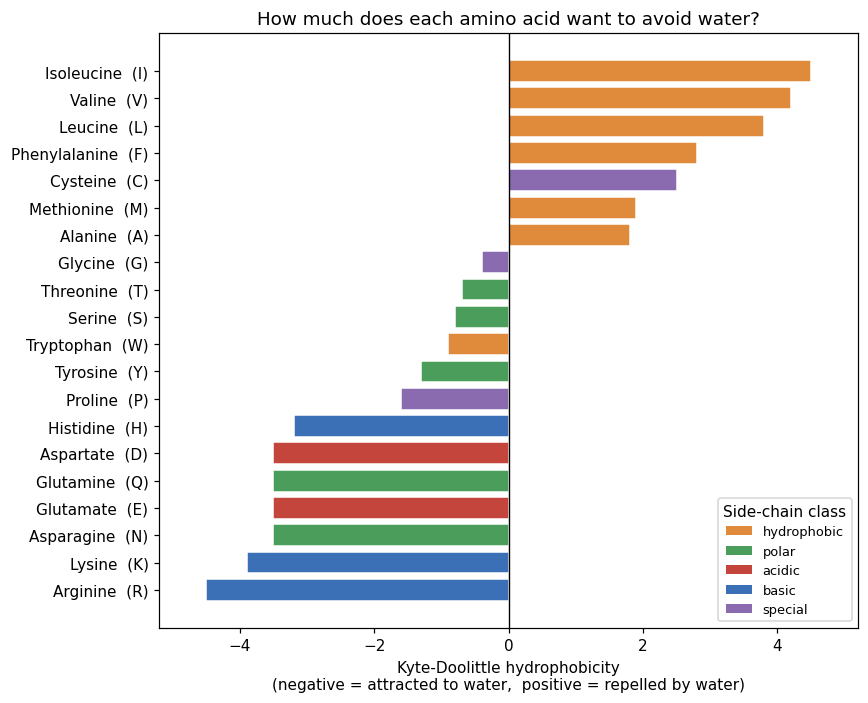

In [5]:
CLASS_COLORS = {
    "hydrophobic": "#E08A3C",   # orange - avoids water
    "polar":       "#4A9D5B",   # green  - hydrogen bonds with water
    "acidic":      "#C4453C",   # red    - negative at pH 7
    "basic":       "#3B6FB6",   # blue   - positive at pH 7
    "special":     "#8A6BAF",   # purple - structural oddballs
}

ordered = aa_table.sort_values("hydrophobicity")

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(ordered["name"] + "  (" + ordered["aa"] + ")", ordered["hydrophobicity"],
        color=[CLASS_COLORS[c] for c in ordered["class"]], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.9)

ax.set_xlabel("Kyte-Doolittle hydrophobicity\n(negative = attracted to water,  positive = repelled by water)")
ax.set_title("How much does each amino acid want to avoid water?")
ax.set_xlim(-5.2, 5.2)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=k) for k, c in CLASS_COLORS.items()],
          loc="lower right", fontsize=8.5, title="Side-chain class")

plt.tight_layout()
plt.show()

### The chart is doing chemistry, not just decoration

Look at how cleanly the colors sort themselves. This is not a coincidence — it's the
periodic-table-level logic of polarity showing up in biology.

**Everything on the positive (right) side is orange or purple.** Isoleucine, valine, leucine,
phenylalanine: these side chains are pure hydrocarbon or aromatic rings. They have no
meaningful dipole moment, so water molecules can't form hydrogen bonds with them. Cysteine
(purple, +2.5) sits up there too — its –SH group is only weakly polar, because sulfur and
hydrogen have nearly identical electronegativities.

**Everything at the far negative (left) end is blue, red, or green.** Arginine bottoms out at
−4.5: its guanidinium group carries a full positive charge spread over three nitrogens, and
a charged group in water is stabilized by strong ion–dipole interactions. Pulling it out of
water would cost a lot of energy. Aspartate and glutamate (red) sit at −3.5 for the mirror-
image reason — full negative charge. Asparagine and glutamine (green) are also at −3.5
despite being *uncharged*, because their amide groups are excellent hydrogen bond donors
**and** acceptors.

**Tryptophan is the interesting exception.** We classified it as hydrophobic — it's a big
aromatic indole ring — yet it scores −0.9, on the water-loving side. That's because the ring
carries an N–H group that can donate a hydrogen bond. Tryptophan is genuinely amphipathic,
and you'll often find it right at the boundary between a protein's core and its surface.
Classification schemes are useful simplifications, not laws of nature, and it's worth
knowing where yours creaks.

Now we have chemistry for all 20 amino acids, and confidence scores for all 148 positions in
lysozyme. Time to put them together.

---

# 3. What is lysozyme made of?

Now we join our two tables: the 148 positions in lysozyme, and the chemistry of the 20 amino
acids. `pandas` does this with `merge()`, matching rows on the shared `aa` column — the same
idea as a lookup in a spreadsheet.

### First, a decision we have to make on purpose

We just discovered that residues 1–18 are a signal peptide that gets **cut off** and is not
part of the working enzyme. So before we analyze anything, we have to answer a question every
experiment has to answer:

> **What exactly is the population we're studying?**

We're asking whether side-chain chemistry explains AlphaFold's confidence *in a folded
protein*. The signal peptide isn't part of the folded protein — it's a shipping label. Mixing
it in would mean testing our idea on a mixture of two completely different things.

So we define our study population as the **mature protein, residues 19–148**, and we do it
*before* looking at any results — not after, once we've seen which choice gives a nicer
answer. That ordering is what separates an analysis from a fishing expedition.

We are not throwing the signal peptide away. We're setting it aside deliberately, and in
section 9 we'll bring it back and see exactly how much difference this one decision makes.

In [6]:
# Join chemistry onto every position in the protein
lyso = lyso.merge(aa_table, on="aa", how="left")
assert lyso["class"].notna().all(), "some residue had no chemistry entry"

SIGNAL_PEPTIDE_END = 18
mature = lyso[lyso["position"] > SIGNAL_PEPTIDE_END].copy()

print(f"Full chain:      {len(lyso)} residues (positions 1-{len(lyso)})")
print(f"Signal peptide:  {SIGNAL_PEPTIDE_END} residues (cleaved off before the enzyme is secreted)")
print(f"Mature enzyme:   {len(mature)} residues (positions {SIGNAL_PEPTIDE_END+1}-{len(lyso)})  <-- our study population")
print()

composition = mature["class"].value_counts()
print("Composition of the mature enzyme:")
for cls_name, n in composition.items():
    print(f"  {cls_name:12s} {n:3d} residues  ({100*n/len(mature):4.1f}%)")

mature[["position", "aa", "name", "class", "hydrophobicity", "charge_at_pH7", "pLDDT"]].head()

Full chain:      148 residues (positions 1-148)
Signal peptide:  18 residues (cleaved off before the enzyme is secreted)
Mature enzyme:   130 residues (positions 19-148)  <-- our study population

Composition of the mature enzyme:
  hydrophobic   45 residues  (34.6%)
  polar         33 residues  (25.4%)
  special       21 residues  (16.2%)
  basic         20 residues  (15.4%)
  acidic        11 residues  ( 8.5%)


,position,aa,name,class,hydrophobicity,charge_at_pH7,pLDDT
18,19,K,Lysine,basic,-3.9,1,95.06
19,20,V,Valine,hydrophobic,4.2,0,98.44
20,21,F,Phenylalanine,hydrophobic,2.8,0,98.69
21,22,E,Glutamate,acidic,-3.5,-1,98.56
22,23,R,Arginine,basic,-4.5,1,98.56


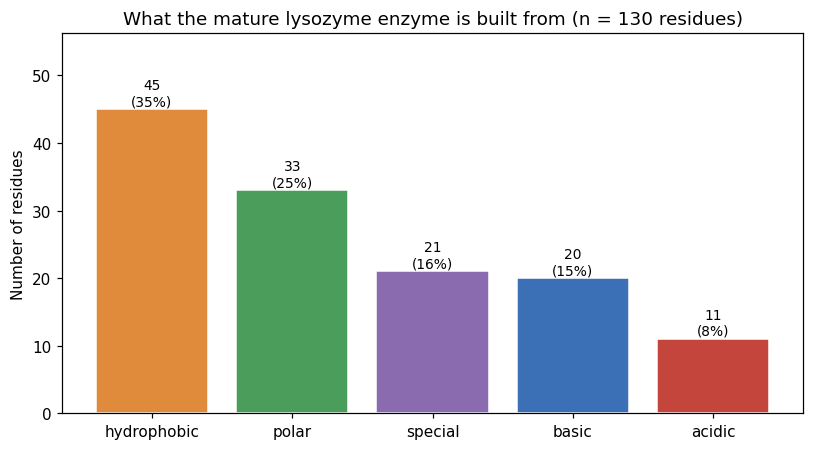

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

order = ["hydrophobic", "polar", "special", "basic", "acidic"]
counts = [composition[c] for c in order]
bars = ax.bar(order, counts, color=[CLASS_COLORS[c] for c in order], edgecolor="white")

for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, n + 0.6,
            f"{n}\n({100*n/len(mature):.0f}%)", ha="center", fontsize=9)

ax.set_ylabel("Number of residues")
ax.set_title(f"What the mature lysozyme enzyme is built from (n = {len(mature)} residues)")
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()
plt.show()

### Reading the composition

Hydrophobic residues are the single largest group — 45 of 130, about 35% of the enzyme.
That's typical, and it's a structural necessity rather than an accident. A protein dissolved
in water needs *something* to hold its folded shape together, and the main thing doing that
job is a core of nonpolar side chains packed away from the solvent.

The charged residues (acidic + basic) come to 31 residues, about 24%. Notice that basic
residues outnumber acidic ones almost 2:1 here. That gives lysozyme a strongly **positive**
net charge at physiological pH — which is not a random detail. Bacterial cell walls are
loaded with negatively charged groups, and Coulombic attraction between the positively
charged enzyme and the negatively charged cell wall helps lysozyme find and stick to its
target. Chemistry you'd meet in AP Chem, doing immunology.

Now for the actual question.

---

# 4. Does confidence differ by side-chain class?

Here's our hypothesis again: **nonpolar residues get buried in the protein's core, buried
residues are locked in place, and locked-in residues should be easier to predict.** If that's
right, hydrophobic residues should have higher pLDDT than charged ones.

To check, we can't just compare the group averages and eyeball it. Any two groups of numbers
will have *slightly* different averages by pure chance. We need to know whether the
difference we see is bigger than the wobble we'd expect from chance alone.

### Three numbers that sound similar and are not

This trips up almost everyone the first time, so let's be precise.

**Standard deviation (SD)** — how spread out the *individual residues* are. A big SD means
the residues in that group have wildly different scores from each other. SD describes the
data you have.

**Standard error (SE)** — how much the *group average* would bounce around if you repeated
the whole study. It's the SD divided by √n. Notice what that means: measuring more residues
doesn't make the individual residues less variable (SD stays put), but it does pin down the
average more tightly (SE shrinks). SE describes how well you know the average.

**95% confidence interval (CI)** — a range built from the SE, roughly `mean ± 2 × SE`. The
honest interpretation: if we repeated this entire procedure many times, about 95% of the
intervals we'd build would contain the true average. It is a statement about the *method's*
reliability, not a promise about this one interval.

The practical rule we'll use: **if two groups' confidence intervals overlap a lot, we don't
have strong evidence that their true averages differ.**

In [8]:
summary_rows = []
for cls_name in order:
    vals = mature.loc[mature["class"] == cls_name, "pLDDT"]
    sem = stats.sem(vals)
    ci_low, ci_high = stats.t.interval(0.95, len(vals) - 1, loc=vals.mean(), scale=sem)
    summary_rows.append({
        "class": cls_name,
        "n": len(vals),
        "mean_pLDDT": round(vals.mean(), 2),
        "SD": round(vals.std(), 2),
        "SE": round(sem, 3),
        "CI_low": round(ci_low, 2),
        "CI_high": round(ci_high, 2),
    })

class_summary = pd.DataFrame(summary_rows)
print("pLDDT by side-chain class, mature enzyme only:\n")
class_summary

pLDDT by side-chain class, mature enzyme only:



,class,n,mean_pLDDT,SD,SE,CI_low,CI_high
0,hydrophobic,45,98.56,0.57,0.085,98.38,98.73
1,polar,33,98.48,0.48,0.083,98.31,98.65
2,special,21,98.24,0.82,0.178,97.87,98.61
3,basic,20,98.32,0.83,0.186,97.93,98.71
4,acidic,11,98.03,1.13,0.341,97.27,98.79


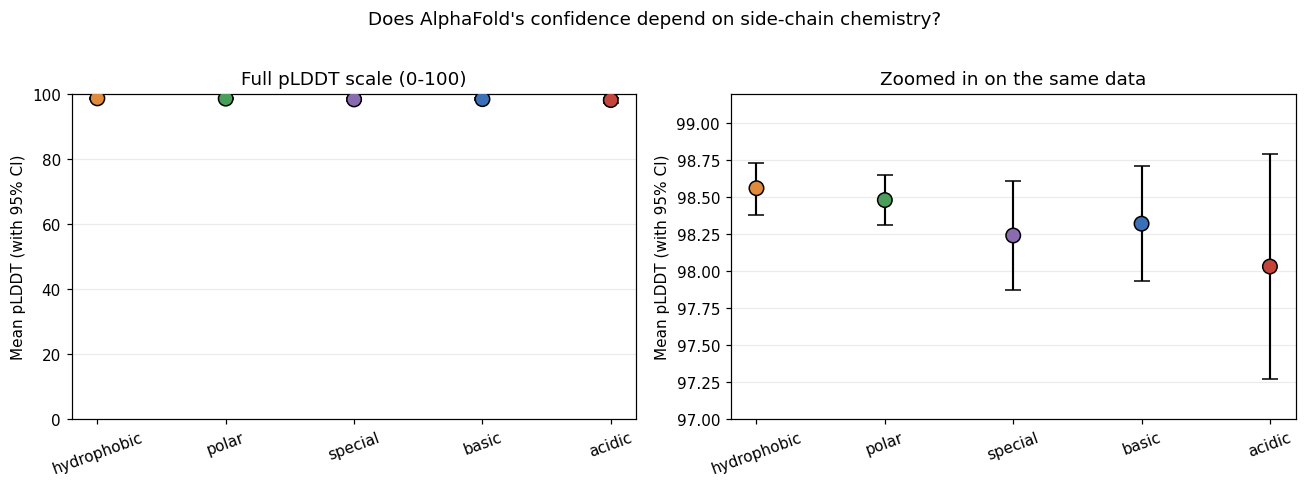

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

x = np.arange(len(class_summary))
colors = [CLASS_COLORS[c] for c in class_summary["class"]]
err = [class_summary["mean_pLDDT"] - class_summary["CI_low"],
       class_summary["CI_high"] - class_summary["mean_pLDDT"]]

for ax, (lo, hi), title in [
    (ax1, (0, 100), "Full pLDDT scale (0-100)"),
    (ax2, (97.0, 99.2), "Zoomed in on the same data"),
]:
    ax.errorbar(x, class_summary["mean_pLDDT"], yerr=err, fmt="none",
                ecolor="black", capsize=5, linewidth=1.4, zorder=3)
    ax.scatter(x, class_summary["mean_pLDDT"], s=90, c=colors,
               edgecolor="black", zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(class_summary["class"], rotation=20)
    ax.set_ylim(lo, hi)
    ax.set_ylabel("Mean pLDDT (with 95% CI)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Does AlphaFold's confidence depend on side-chain chemistry?", y=1.02)
plt.tight_layout()
plt.show()

### Look at those two panels side by side

Same numbers. Same error bars. Completely different impression.

On the **left**, plotted on the real 0–100 scale that pLDDT actually lives on, all five
classes are indistinguishable. The dots sit on top of each other and the error bars are too
small to even see.

On the **right**, we zoomed the y-axis to a 2.2-unit window and suddenly there appear to be
dramatic differences between classes, with acidic residues way down at the bottom.

**Nothing changed except the axis.** This is one of the most common ways charts mislead
people — including the person making them. Whenever you see a bar chart with a suspiciously
narrow y-axis, or one that doesn't start at zero, ask what it would look like at full scale.

The left panel is telling the truth: every class averages between **98.03 and 98.56**, a
spread of about half a point on a hundred-point scale. Notice also that the acidic group's
error bars are much wider — that's because there are only 11 acidic residues versus 45
hydrophobic ones, and SE shrinks with √n. Small group, fuzzy estimate.

Let's put a number on it anyway.

In [10]:
hydrophobic = mature.loc[mature["class"] == "hydrophobic", "pLDDT"]
charged = mature.loc[mature["class"].isin(["acidic", "basic"]), "pLDDT"]

t_stat, p_value = stats.ttest_ind(hydrophobic, charged, equal_var=False)   # Welch's t-test

# Cohen's d: how big is the gap, measured in standard deviations?
pooled_sd = np.sqrt(((len(hydrophobic) - 1) * hydrophobic.var(ddof=1) +
                     (len(charged) - 1) * charged.var(ddof=1)) /
                    (len(hydrophobic) + len(charged) - 2))
cohens_d = (hydrophobic.mean() - charged.mean()) / pooled_sd

print("Hypothesis: hydrophobic residues have HIGHER pLDDT than charged residues")
print("-" * 62)
print(f"Hydrophobic:  n = {len(hydrophobic):3d}   mean = {hydrophobic.mean():.2f}   SD = {hydrophobic.std():.2f}")
print(f"Charged:      n = {len(charged):3d}   mean = {charged.mean():.2f}   SD = {charged.std():.2f}")
print(f"Difference:                  {hydrophobic.mean() - charged.mean():+.2f} pLDDT points")
print()
print(f"Welch's t-test:   t = {t_stat:.3f},  p = {p_value:.4f}")
print(f"Cohen's d:        d = {cohens_d:.3f}")
print()
print("Verdict at the conventional 0.05 threshold:",
      "REJECT the null" if p_value < 0.05 else "FAIL to reject the null (no convincing evidence)")

Hypothesis: hydrophobic residues have HIGHER pLDDT than charged residues
--------------------------------------------------------------
Hydrophobic:  n =  45   mean = 98.56   SD = 0.57
Charged:      n =  31   mean = 98.22   SD = 0.94
Difference:                  +0.34 pLDDT points

Welch's t-test:   t = 1.795,  p = 0.0794
Cohen's d:        d = 0.457

Verdict at the conventional 0.05 threshold: FAIL to reject the null (no convincing evidence)


### Our hypothesis just failed, and that's fine

The difference goes in the predicted direction — hydrophobic residues do average slightly
higher — but **p = 0.079**, above the conventional 0.05 cutoff. In plain language:

> If side-chain chemistry made no difference at all to pLDDT, we'd still see a gap this big
> or bigger about 8% of the time, purely by chance. That's not rare enough to be convincing.

Three things worth taking from this.

**1. A *p*-value is not the probability that your hypothesis is wrong.** It's the probability
of seeing data at least this extreme *if the null hypothesis were true*. Those are genuinely
different statements, and mixing them up is the single most common statistical error in
published science.

**2. Effect size and significance are different questions.** Cohen's *d* = 0.457 is a
"moderate" effect by the usual rule of thumb — but *d* is measured in standard deviations,
and the standard deviations here are tiny (0.57 and 0.94 points). Half a standard deviation
of almost nothing is still almost nothing. Always ask "how big, in units I care about?"
alongside "is it significant?" Here the answer is **0.34 pLDDT points** on a 100-point scale.
Nobody would make a different decision about a protein based on that.

**3. There's a reason the effect is invisible: we've hit a ceiling.** Across the entire mature
enzyme, pLDDT runs from 95.1 to 98.9 with a standard deviation of just 0.71. AlphaFold is
essentially *maxed out* on this protein. You cannot detect what makes confidence vary when
confidence barely varies. A well-folded protein is a wonderfully clean subject in every way
except this one — there's no variation left to explain.

That's a real, honest finding, and reporting it is not a failure. Papers that only ever
confirm their hypothesis should make you suspicious.

But before we give up on chemistry, we should ask whether we tested the right thing.